In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# fs = 100
# dt = 1 / fs


In [23]:
df_cuat = pd.read_csv(r"06_05_2026\100\QuaternionEst__3.csv")

df_imu = pd.read_csv(r"06_05_2026\100\SensorConnectData__3.csv")

start_time_hhmmss = "16:19:20.26"

zupt_periods_hhmmss = [
    ("16:19:20.26", "16:19:38.00"),
    ("16:20:15.00", "16:20:35.00"),
    ("16:21:05.00", "16:21:33.67"),
]

In [24]:
df_cuat

,Time,fGPS_ts,estOrientQuaternion[0],estOrientQuaternion[1],estOrientQuaternion[2],estOrientQuaternion[3],estOrientQuaternion:valid,flag
0,1778107667594,698.362,0.999522,-0.030097,0.007037,0.000508,1,0
1,1778107667594,698.382,0.999524,-0.030023,0.007028,0.000497,1,0
2,1778107667594,698.407,0.999528,-0.029913,0.007015,0.000490,1,0
3,1778107667594,698.432,0.999530,-0.029851,0.007011,0.000490,1,0
4,1778107667594,698.452,0.999531,-0.029793,0.007013,0.000486,1,0
...,...,...,...,...,...,...,...,...
1790,1778107709229,760.707,0.713668,-0.007708,0.001953,0.700439,1,1
1791,1778107709254,760.732,0.713649,-0.007764,0.001930,0.700458,1,1
1792,1778107709276,760.752,0.713633,-0.007810,0.001897,0.700474,1,1
1793,1778107709299,760.777,0.713625,-0.007856,0.001849,0.700482,1,1


In [25]:
# Renombrar columnas
cuat_new_names = ["q0", "q1", "q2", "q3", "zupt_flag"]
df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[2:6], cuat_new_names[:4])))

# df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[-1], cuat_new_names[-1])))
df_cuat = df_cuat.rename(columns={df_cuat.columns[-1]: cuat_new_names[-1]})

# Tiempo relativo en segundos
df_cuat["t"] = (df_cuat["Time"] - df_cuat["Time"].iloc[0]) / 1e3

# Delta de tiempo entre muestra
df_cuat["dt"] = df_cuat["t"].diff()

# Reordenar columnas
df_cuat = df_cuat.reindex(columns=['Time', 't', 'dt', 'q0', 'q1', 'q2', 'q3' ,'zupt_flag'])

df_cuat

,Time,t,dt,q0,q1,q2,q3,zupt_flag
0,1778107667594,0.000,NaN,0.999522,-0.030097,0.007037,0.000508,0
1,1778107667594,0.000,0.000,0.999524,-0.030023,0.007028,0.000497,0
2,1778107667594,0.000,0.000,0.999528,-0.029913,0.007015,0.000490,0
3,1778107667594,0.000,0.000,0.999530,-0.029851,0.007011,0.000490,0
4,1778107667594,0.000,0.000,0.999531,-0.029793,0.007013,0.000486,0
...,...,...,...,...,...,...,...,...
1790,1778107709229,41.635,0.023,0.713668,-0.007708,0.001953,0.700439,1
1791,1778107709254,41.660,0.025,0.713649,-0.007764,0.001930,0.700458,1
1792,1778107709276,41.682,0.022,0.713633,-0.007810,0.001897,0.700474,1
1793,1778107709299,41.705,0.023,0.713625,-0.007856,0.001849,0.700482,1


In [26]:
list(df_imu.columns.values)

['Time',
 'GPS_ts',
 'fGPS_ts',
 'scaledAccelX',
 'scaledAccelY',
 'scaledAccelZ',
 'deltaVelX',
 'deltaVelY',
 'deltaVelZ',
 'estLinearAccelX',
 'estLinearAccelY',
 'estLinearAccelZ',
 'estLinearAccel:valid',
 'estAngularRateX',
 'estAngularRateY',
 'estAngularRateZ',
 'estAngularRate:valid',
 'estGravityX',
 'estGravityY',
 'estGravityZ',
 'estGravity:valid',
 'flag']

In [27]:
al_new_names = ["alx", "aly", "alz"]

df_imu = df_imu.rename(columns=dict(zip(df_imu.columns[9:13], al_new_names)))

df_imu = df_imu.reindex(columns=["Time", "alx", "aly", "alz"])

df_imu

,Time,alx,aly,alz
0,1778107667594,0.011772,-0.051423,0.038865
1,1778107667594,0.015049,-0.053162,0.039543
2,1778107667594,-0.006308,-0.057086,0.020754
3,1778107667594,-0.014528,-0.050194,0.039730
4,1778107667594,-0.012818,-0.061213,0.039085
...,...,...,...,...
4057,1778107762270,0.035531,-0.017076,0.050648
4058,1778107762297,0.022978,-0.041754,0.045800
4059,1778107762318,0.031540,-0.011603,0.043094
4060,1778107762340,0.047333,-0.001168,0.042570


In [28]:
tol_ns = 5_000_000  # 5 ms

df_u = pd.merge_asof(
    df_cuat,
    df_imu,
    on="Time",
    direction="nearest",
    tolerance=tol_ns
)

# Eliminar filas donde no hubo coincidencia dentro de la tolerancia
df_u = df_u.dropna(
    subset=["q0"]
).reset_index(drop=True)

df_u

,Time,t,dt,q0,q1,q2,q3,zupt_flag,alx,aly,alz
0,1778107667594,0.000,NaN,0.999522,-0.030097,0.007037,0.000508,0,0.009636,-0.055577,0.046035
1,1778107667594,0.000,0.000,0.999524,-0.030023,0.007028,0.000497,0,0.009636,-0.055577,0.046035
2,1778107667594,0.000,0.000,0.999528,-0.029913,0.007015,0.000490,0,0.009636,-0.055577,0.046035
3,1778107667594,0.000,0.000,0.999530,-0.029851,0.007011,0.000490,0,0.009636,-0.055577,0.046035
4,1778107667594,0.000,0.000,0.999531,-0.029793,0.007013,0.000486,0,0.009636,-0.055577,0.046035
...,...,...,...,...,...,...,...,...,...,...,...
1790,1778107709229,41.635,0.023,0.713668,-0.007708,0.001953,0.700439,1,-0.001132,-0.003280,0.008190
1791,1778107709254,41.660,0.025,0.713649,-0.007764,0.001930,0.700458,1,0.014261,-0.012613,0.032375
1792,1778107709276,41.682,0.022,0.713633,-0.007810,0.001897,0.700474,1,-0.000541,0.000376,0.082572
1793,1778107709299,41.705,0.023,0.713625,-0.007856,0.001849,0.700482,1,-0.026658,0.010856,0.002687


In [29]:
# Validación

print(df_u["dt"].describe())

fs_mean = 1 / df_u["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    1794.000000
mean        0.023261
std         0.002806
min         0.000000
25%         0.022000
50%         0.022000
75%         0.026000
max         0.027000
Name: dt, dtype: float64
Frecuencia promedio: 42.99 Hz


In [30]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def ins_strapdown_dead_reckoning(
    df,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    # Columna ZUPT desde la tabla
    zupt_flag_col="zupt_flag",

    # Ganancias generales
    G_acc=1.0,
    p_gain=1.0,

    # ZUPT por flag
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    # Non-Holonomic Constraints
    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    # Convención de rotación
    use_transpose=True,

    # Opciones
    normalize_quat=True,
    verbose=True
):
    """
    INS strapdown básico para Dead Reckoning usando:
        - aceleración lineal en body
        - cuaternión de orientación
        - ZUPT activado por columna zupt_flag
        - NHC para vehículo terrestre

    La columna zupt_flag debe contener:
        0 -> no aplicar ZUPT
        1 -> aplicar ZUPT
    """

    df_out = df.copy()

    # -----------------------------
    # Validaciones mínimas
    # -----------------------------
    required_cols = list(acc_cols) + list(quat_cols) + [time_col, dt_col, zupt_flag_col]
    missing = [c for c in required_cols if c not in df_out.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # Convertir a numérico
    for c in required_cols:
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    # Por seguridad, la flag se fuerza a 0/1
    df_out[zupt_flag_col] = df_out[zupt_flag_col].fillna(0).astype(int)

    # Inicialización
    p = np.zeros(3, dtype=float)
    v = np.zeros(3, dtype=float)

    # Crear columnas de salida
    output_cols = [
        "a_nav_x", "a_nav_y", "a_nav_z",
        "a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc",
        "a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc",
        "v_int_x", "v_int_y", "v_int_z",
        "vx_body_raw", "vy_body_raw", "vz_body_raw",
        "vx_body_nhc", "vy_body_nhc", "vz_body_nhc",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "px_scale", "py_scale", "pz_scale",
        "zupt_applied"
    ]

    for col in output_cols:
        df_out[col] = np.nan

    # -----------------------------
    # Loop strapdown
    # -----------------------------
    for k in range(len(df_out)):

        t = df_out.loc[k, time_col]
        dt = df_out.loc[k, dt_col]

        # Leer flag ZUPT desde la tabla
        zupt_flag = int(df_out.loc[k, zupt_flag_col])

        # Para la primera fila normalmente dt es NaN
        if pd.isna(t) or pd.isna(dt) or dt <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        # -----------------------------
        # 1. Leer aceleración en body
        # -----------------------------
        a_body = df_out.loc[k, list(acc_cols)].to_numpy(dtype=float)

        if np.any(np.isnan(a_body)):
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        # -----------------------------
        # 2. Leer y normalizar cuaternión
        # -----------------------------
        q = df_out.loc[k, list(quat_cols)].to_numpy(dtype=float)

        if np.any(np.isnan(q)):
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        q_norm = np.linalg.norm(q)

        if q_norm <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        if normalize_quat:
            q = q / q_norm

        q0, q1, q2, q3 = q

        # scipy usa formato [x, y, z, w]
        r = R.from_quat([q1, q2, q3, q0])

        if use_transpose:
            R_nb = r.as_matrix().T
        else:
            R_nb = r.as_matrix()

        # -----------------------------
        # 3. Aceleración body -> navegación
        # -----------------------------
        a_nav = G_acc * (R_nb @ a_body)

        df_out.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

        # -----------------------------
        # 4. Integración de velocidad libre
        # -----------------------------
        v = v + a_nav * dt

        df_out.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        # -----------------------------
        # 5. ZUPT usando flag de la tabla
        # -----------------------------
        df_out.loc[k, "zupt_applied"] = zupt_flag

        if zupt_flag == 1:
            if hard_zupt:
                v[:] = 0.0
            else:
                v = v - ZUPT_GAIN * v

        # -----------------------------
        # 6. NHC: velocidad nav -> body
        # -----------------------------
        a_nav_nhc = a_nav.copy()

        if use_nhc:
            v_body = R_nb.T @ v

            df_out.loc[k, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

            # Forma recomendable usando tus ganancias
            # x: avance longitudinal
            # y: velocidad lateral
            # z: velocidad vertical
            v_body[1] = v_body[1] * (1.0 - K_nhc_y)
            v_body[2] = v_body[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]] = v_body

            # Volver velocidad a navegación
            v = R_nb @ v_body

            # Opcional: aceleración también restringida en body
            a_body_nhc = a_body.copy()
            a_body_nhc[1] = a_body_nhc[1] * (1.0 - K_nhc_y)
            a_body_nhc[2] = a_body_nhc[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]] = a_body_nhc

            a_nav_nhc = R_nb @ a_body_nhc

            df_out.loc[k, ["a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc"]] = a_nav_nhc

        # -----------------------------
        # 7. Integración de posición
        # -----------------------------
        p = p + v * dt

        p_scale = p_gain * p

        df_out.loc[k, ["vx", "vy", "vz"]] = v
        df_out.loc[k, ["px", "py", "pz"]] = p
        df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale

    if verbose:
        print("INS strapdown finalizado.")
        print(f"Filas procesadas: {len(df_out)}")
        print(f"Posición final [m]: {p}")
        print(f"Velocidad final [m/s]: {v}")
        print(f"Muestras con ZUPT aplicado: {df_out['zupt_applied'].sum()}")

    return df_out

In [31]:
import pandas as pd
import numpy as np


def hhmmss_to_seconds(hhmmss):
    """
    Convierte una hora tipo:
        '16:46:25.77'
        '16:47:00.7'
        '16:47:27'
    a segundos desde las 00:00:00.
    """

    parts = hhmmss.strip().split(":")

    if len(parts) != 3:
        raise ValueError(f"Formato inválido: {hhmmss}. Usa HH:MM:SS.sss")

    h = int(parts[0])
    m = int(parts[1])
    s = float(parts[2])

    return h * 3600 + m * 60 + s


def convert_zupt_periods_hhmmss_to_relative(zupt_periods_hhmmss, start_time_hhmmss):
    """
    Convierte periodos ZUPT dados en hora real HH:MM:SS.sss
    a periodos relativos en segundos respecto a start_time_hhmmss.

    Ejemplo:
        start_time_hhmmss = '16:46:09.77'

        zupt_periods_hhmmss = [
            ('16:46:25.77', '16:46:30.25'),
            ('16:46:52.64', '16:47:00.7')
        ]

    Retorna:
        [
            (16.0, 20.48),
            (42.87, 50.93)
        ]
    """

    t0_abs = hhmmss_to_seconds(start_time_hhmmss)

    zupt_periods_rel = []

    for t_ini_str, t_fin_str in zupt_periods_hhmmss:
        t_ini_abs = hhmmss_to_seconds(t_ini_str)
        t_fin_abs = hhmmss_to_seconds(t_fin_str)

        t_ini_rel = t_ini_abs - t0_abs
        t_fin_rel = t_fin_abs - t0_abs

        if t_fin_rel < t_ini_rel:
            raise ValueError(
                f"Periodo inválido: {t_ini_str} - {t_fin_str}. "
                "El tiempo final es menor que el inicial."
            )

        zupt_periods_rel.append((t_ini_rel, t_fin_rel))

    return zupt_periods_rel

In [32]:
zupt_periods = convert_zupt_periods_hhmmss_to_relative(
    zupt_periods_hhmmss,
    start_time_hhmmss
)

print(zupt_periods)

[(0.0, 17.739999999997963), (54.73999999999796, 74.73999999999796), (104.73999999999796, 133.40999999999622)]


In [33]:
# # Periodos donde sabes que el vehículo está detenido

# zupt_periods = [
#     #  t_inicio, t_final
#     (0, 18),    # detenido al inicio
#     (55, 75),
#     (105, 133),  # detenido al final
# ]

In [34]:
df_ins = ins_strapdown_dead_reckoning(
    df=df_u,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    G_acc=1.0,
    p_gain=1.0,

    # zupt_periods=zupt_periods,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    use_transpose=True
)

df_ins.head()

INS strapdown finalizado.
Filas procesadas: 1795
Posición final [m]: [  7.92415783 -16.92794665   0.99285975]
Velocidad final [m/s]: [0. 0. 0.]
Muestras con ZUPT aplicado: 540.0


,Time,t,dt,q0,q1,q2,q3,zupt_flag,alx,aly,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1778107667594,0.0,NaN,0.999522,-0.030097,0.007037,0.000508,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1778107667594,0.0,0.0,0.999524,-0.030023,0.007028,0.000497,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1778107667594,0.0,0.0,0.999528,-0.029913,0.007015,0.000490,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1778107667594,0.0,0.0,0.999530,-0.029851,0.007011,0.000490,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1778107667594,0.0,0.0,0.999531,-0.029793,0.007013,0.000486,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
df_ins.head

<bound method NDFrame.head of                Time       t     dt        q0        q1        q2        q3  \
0     1778107667594   0.000    NaN  0.999522 -0.030097  0.007037  0.000508   
1     1778107667594   0.000  0.000  0.999524 -0.030023  0.007028  0.000497   
2     1778107667594   0.000  0.000  0.999528 -0.029913  0.007015  0.000490   
3     1778107667594   0.000  0.000  0.999530 -0.029851  0.007011  0.000490   
4     1778107667594   0.000  0.000  0.999531 -0.029793  0.007013  0.000486   
...             ...     ...    ...       ...       ...       ...       ...   
1790  1778107709229  41.635  0.023  0.713668 -0.007708  0.001953  0.700439   
1791  1778107709254  41.660  0.025  0.713649 -0.007764  0.001930  0.700458   
1792  1778107709276  41.682  0.022  0.713633 -0.007810  0.001897  0.700474   
1793  1778107709299  41.705  0.023  0.713625 -0.007856  0.001849  0.700482   
1794  1778107709325  41.731  0.026  0.713625 -0.007869  0.001841  0.700481   

      zupt_flag       alx       a

In [36]:
# v_cols=("vx_body_raw", "vy_body_raw", "vz_body_raw")

# v_body = df_ins.loc[2000, list(v_cols)].to_numpy(dtype=float)

# # df_u.loc[2000, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

# print(v_body)
# print(v_body.shape)


# # Restricción no holonómica:
# # vehículo no debería desplazarse lateral ni verticalmente
# # v_body[1] = v_body[1] * (1.0 - K_nhc_y)
# # v_body[2] = v_body[2] * (1.0 - K_nhc_z)
# B = np.array([1, 0, 0])
# print(B)
# print(B.shape)
# v_body = v_body * B
# print(v_body)

In [37]:
df_ins

,Time,t,dt,q0,q1,q2,q3,zupt_flag,alx,aly,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1778107667594,0.000,NaN,0.999522,-0.030097,0.007037,0.000508,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
1,1778107667594,0.000,0.000,0.999524,-0.030023,0.007028,0.000497,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
2,1778107667594,0.000,0.000,0.999528,-0.029913,0.007015,0.000490,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
3,1778107667594,0.000,0.000,0.999530,-0.029851,0.007011,0.000490,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
4,1778107667594,0.000,0.000,0.999531,-0.029793,0.007013,0.000486,0,0.009636,-0.055577,...,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,1778107709229,41.635,0.023,0.713668,-0.007708,0.001953,0.700439,1,-0.001132,-0.003280,...,0.0,0.0,0.0,7.924158,-16.927947,0.99286,7.924158,-16.927947,0.99286,1.0
1791,1778107709254,41.660,0.025,0.713649,-0.007764,0.001930,0.700458,1,0.014261,-0.012613,...,0.0,0.0,0.0,7.924158,-16.927947,0.99286,7.924158,-16.927947,0.99286,1.0
1792,1778107709276,41.682,0.022,0.713633,-0.007810,0.001897,0.700474,1,-0.000541,0.000376,...,0.0,0.0,0.0,7.924158,-16.927947,0.99286,7.924158,-16.927947,0.99286,1.0
1793,1778107709299,41.705,0.023,0.713625,-0.007856,0.001849,0.700482,1,-0.026658,0.010856,...,0.0,0.0,0.0,7.924158,-16.927947,0.99286,7.924158,-16.927947,0.99286,1.0


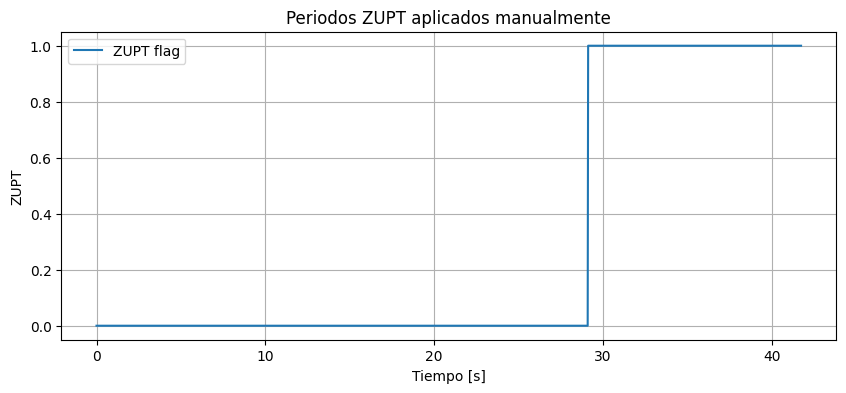

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(df_ins["t"], df_ins["zupt_flag"], label="ZUPT flag")
plt.xlabel("Tiempo [s]")
plt.ylabel("ZUPT")
plt.title("Periodos ZUPT aplicados manualmente")
plt.grid(True)
plt.legend()
plt.show()

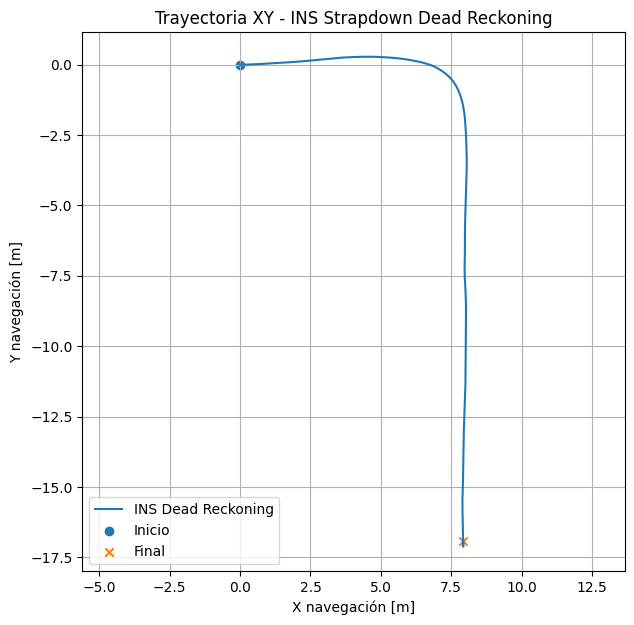

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_ins["px"], df_ins["py"], label="INS Dead Reckoning")

plt.scatter(df_ins["px"].iloc[0], df_ins["py"].iloc[0], label="Inicio", marker="o")
plt.scatter(df_ins["px"].iloc[-1], df_ins["py"].iloc[-1], label="Final", marker="x")

plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.title("Trayectoria XY - INS Strapdown Dead Reckoning")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

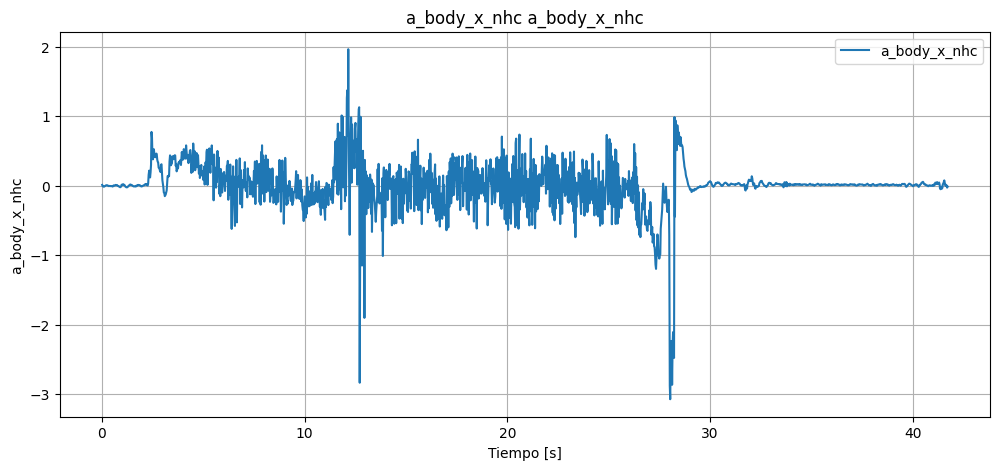

In [40]:
# for col in ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]:
col = "a_body_x_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("a_body_x_nhc")
plt.title(f"a_body_x_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()

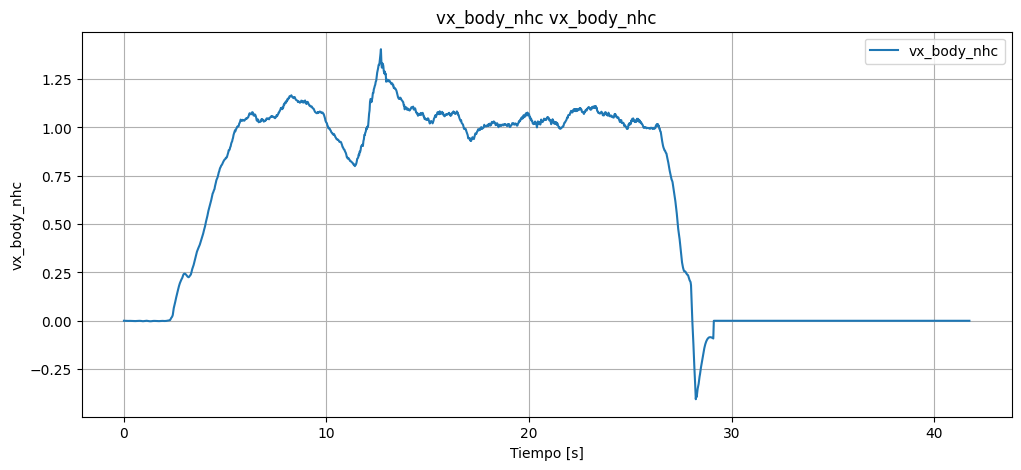

In [41]:
# for col in ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]:
col = "vx_body_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("vx_body_nhc")
plt.title(f"vx_body_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()


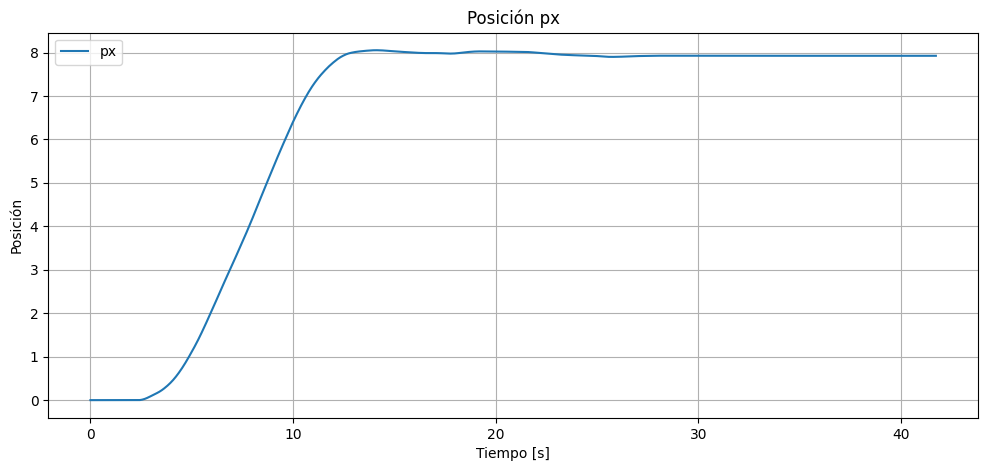

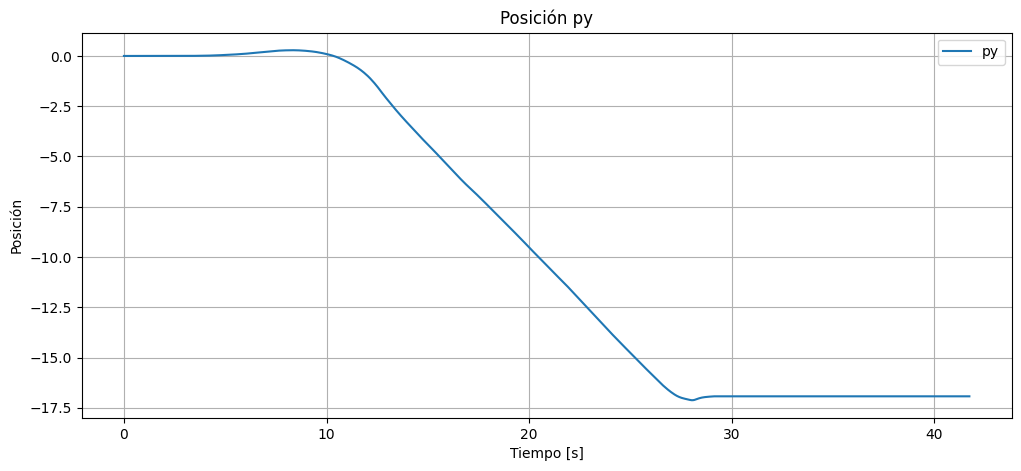

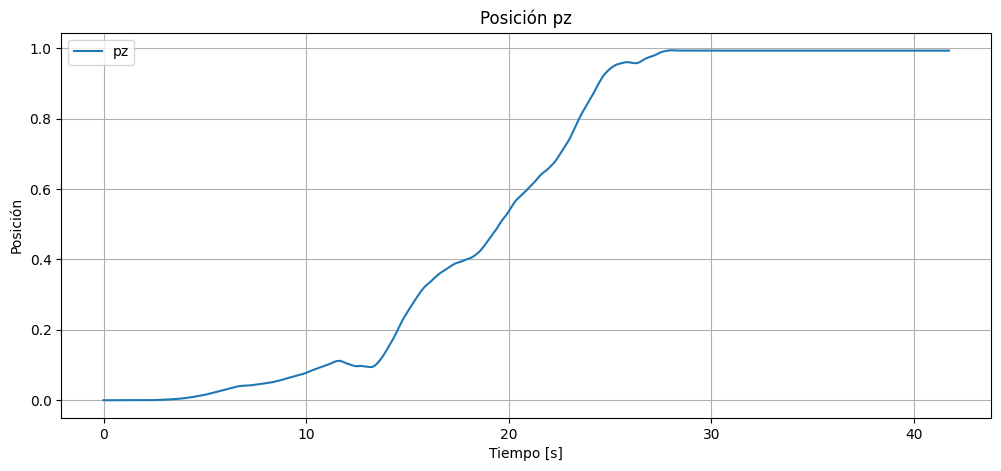

In [42]:
for col in ["px", "py", "pz"]:
    plt.figure(figsize=(12, 5))
    plt.plot(df_ins["t"], df_ins[col], label=col)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Posición")
    plt.title(f"Posición {col}")
    plt.legend()
    plt.grid(True)
    plt.show()